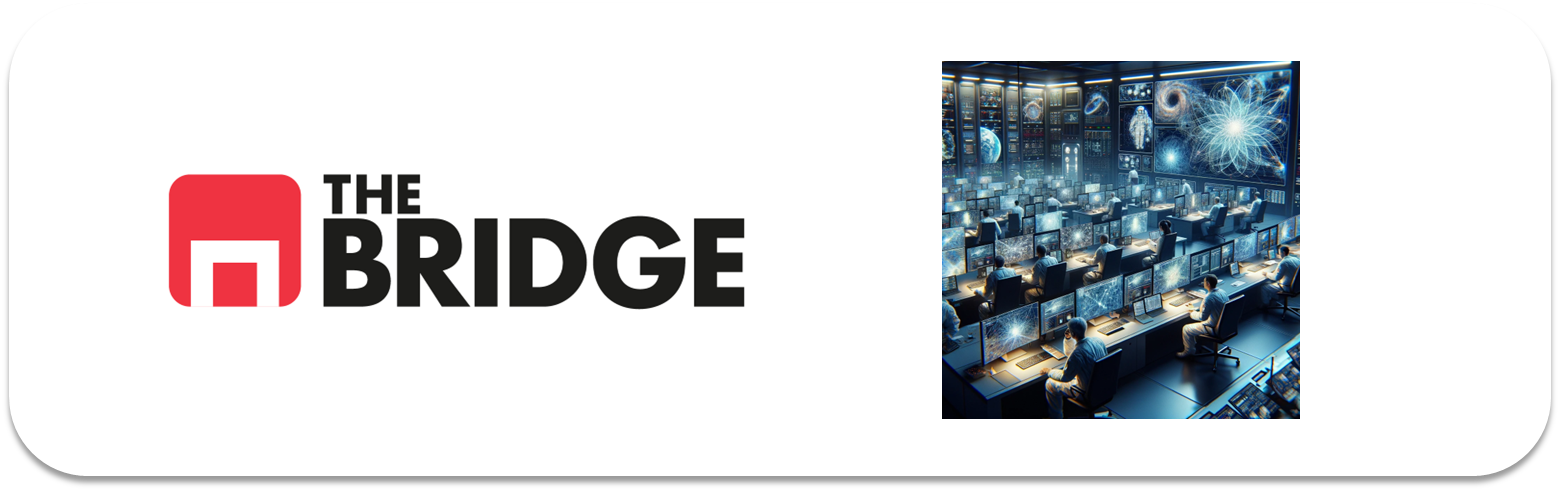

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [1]:
import cv2
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd
import seaborn as sns
from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import time
import gc

pd.options.mode.copy_on_write = True  # CoW por defecto a partir de pandas 3.0.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6692\722369965.py:15: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True  # CoW por defecto a partir de pandas 3.0.0


In [2]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.gpu_device_name())


Num GPUs Available:  0



In [3]:
def show_images_batch(pets, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, pet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(pet, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

def show_images_files(pets, names = [], n_cols = 5, size_scale = 2, train = True, indice = 0):
    n_rows = ((len(pets) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, filepet in enumerate(pets):
        plt.subplot(n_rows, n_cols, index + 1)


In [4]:
TRAIN_PATH = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_train/seg_train"
TEST_PATH = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/seg_test/seg_test"

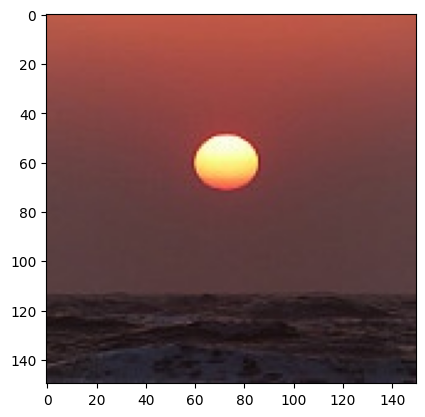

In [5]:
plt.imshow(imread(TRAIN_PATH + "/sea/" + "11321.jpg"))
plt.show()

In [6]:
imread(TRAIN_PATH + "/sea/" + "11321.jpg").shape

(150, 150, 3)

In [7]:
IMG_WIDTH = IMG_HEIGHT = 224

In [8]:
def read_data(directorio, reshape_dim=(IMG_WIDTH, IMG_HEIGHT)):
    X = []
    y = []
    
    for folder in os.listdir(directorio):
        folder_path = os.path.join(directorio, folder)
        
        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)
                
                # Redimensionamos las imágenes a 75x75
                img = cv2.resize(imread(file_path), reshape_dim)
                
                X.append(img)
                y.append(folder)
    
    return np.array(X), np.array(y)

In [9]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

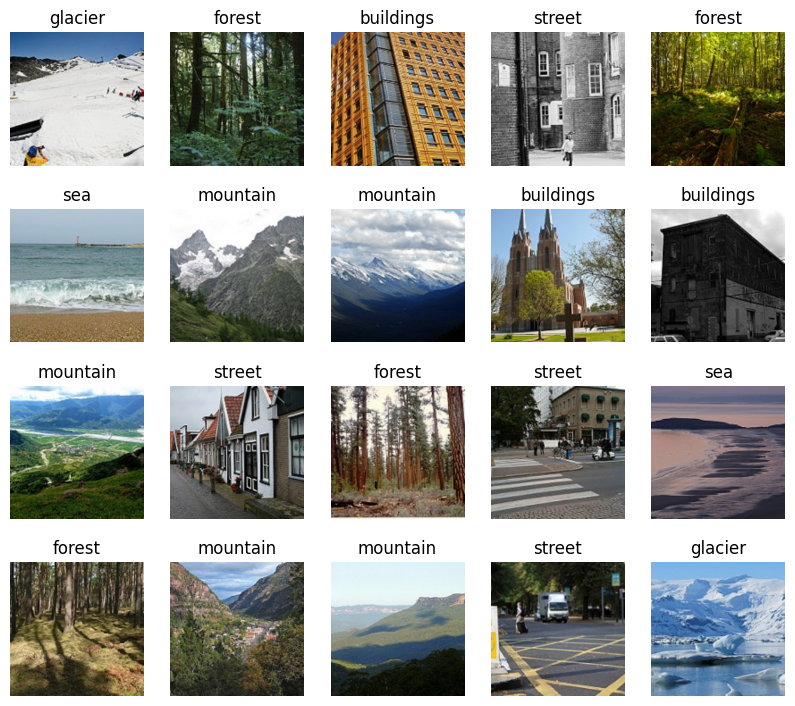

In [10]:
indices = np.random.randint(0, len(X_train), 20)

# Ver 20 imágenes aleatorias

show_images_batch(X_train[indices], names = y_train[indices], n_cols = 5)


In [11]:
# Comprobamos dimensiones

print(X_train.shape)
print(X_test.shape)

(14034, 224, 224, 3)
(3000, 224, 224, 3)


In [12]:
# conjunto total del shape (14034*75*75*3)
X_train.size

2112509952

In [13]:
# Distribución de clases
pd.Series(y_train).value_counts(normalize=True)

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64

In [14]:
# Convertir etiquetas a números
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

class_names = le.classes_
num_classes = len(class_names)

print(class_names)
print(num_classes)


['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
6


In [15]:
# Normalizar imágenes
X_train_norm = X_train / 255.0
X_test_norm  = X_test / 255.0


In [16]:
# Crear conjunto de validación
from sklearn.model_selection import train_test_split

X_train_norm, X_val_norm, y_train, y_val = train_test_split(
    X_train_norm, y_train, test_size=0.15, stratify=y_train, random_state=42
)

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_norm, y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val_norm, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test_norm, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)


In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)


In [19]:
num_classes = len(np.unique(y_train))

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_tl = models.Model(inputs, outputs)


In [20]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


373/373 ━━━━━━━━━━━━━━━━━━━━ 116s 271ms/step - accuracy: 0.2681 - loss: 1.7025 - val_accuracy: 0.3224 - val_loss: 1.5670
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 101s 272ms/step - accuracy: 0.3306 - loss: 1.5460 - val_accuracy: 0.4269 - val_loss: 1.4472
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 102s 274ms/step - accuracy: 0.3756 - loss: 1.4602 - val_accuracy: 0.4710 - val_loss: 1.3795
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 111s 296ms/step - accuracy: 0.3982 - loss: 1.3985 - val_accuracy: 0.4791 - val_loss: 1.3055
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 114s 305ms/step - accuracy: 0.4202 - loss: 1.3570 - val_accuracy: 0.5090 - val_loss: 1.2681
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 113s 303ms/step - accuracy: 0.4349 - loss: 1.3289 - val_accuracy: 0.5228 - val_loss: 1.2477
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 114s 305ms/step - accuracy: 0.4292 - loss: 1.3222 - val_accuracy: 0.5294 - val_loss: 1.2313
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 116s 310ms/step - accuracy: 0.4412 - loss: 1.30

In [21]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
test_loss_tl, test_acc_tl = model_tl.evaluate(test_ds)
print("Transfer Learning - Test accuracy:", test_acc_tl)


94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 383ms/step - accuracy: 0.5510 - loss: 1.1793
Transfer Learning - Test accuracy: 0.5509999990463257


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_tl = np.argmax(model_tl.predict(X_test_norm), axis=1)

print(classification_report(y_test, y_pred_tl, target_names=class_names))

cm_tl = confusion_matrix(y_test, y_pred_tl)


94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step
              precision    recall  f1-score   support

   buildings       0.60      0.62      0.61       437
      forest       0.68      0.83      0.75       474
     glacier       0.47      0.44      0.45       553
    mountain       0.52      0.55      0.54       525
         sea       0.55      0.43      0.48       510
      street       0.47      0.48      0.47       501

    accuracy                           0.55      3000
   macro avg       0.55      0.56      0.55      3000
weighted avg       0.55      0.55      0.55      3000



In [27]:
# Descongelamos parte de la base
base_model.trainable = True

# Congelamos las primeras ~100 capas para evitar destruir lo aprendido
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompilamos con LR más pequeño
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


373/373 ━━━━━━━━━━━━━━━━━━━━ 229s 587ms/step - accuracy: 0.5180 - loss: 1.3586 - val_accuracy: 0.1795 - val_loss: 5.0530
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 189s 507ms/step - accuracy: 0.6638 - loss: 0.9012 - val_accuracy: 0.1619 - val_loss: 5.5405
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 189s 508ms/step - accuracy: 0.7137 - loss: 0.7810 - val_accuracy: 0.1690 - val_loss: 1.9263
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 186s 498ms/step - accuracy: 0.7352 - loss: 0.7227 - val_accuracy: 0.1728 - val_loss: 3.5469
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 494ms/step - accuracy: 0.7556 - loss: 0.6710 - val_accuracy: 0.2051 - val_loss: 2.0420
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 183s 492ms/step - accuracy: 0.7704 - loss: 0.6273 - val_accuracy: 0.1942 - val_loss: 2.7422
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 493ms/step - accuracy: 0.7868 - loss: 0.5888 - val_accuracy: 0.3300 - val_loss: 2.4107
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 494ms/step - accuracy: 0.7997 - loss: 0.55

In [28]:
# Volvemos a congelar todo
base_model.trainable = False

# Descongelamos SOLO las últimas 40 capas
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Recompilamos con LR MUY pequeño
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 145s 370ms/step - accuracy: 0.7787 - loss: 0.6006 - val_accuracy: 0.4202 - val_loss: 1.7156
Epoch 2/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 169s 454ms/step - accuracy: 0.8106 - loss: 0.5226 - val_accuracy: 0.5304 - val_loss: 1.2191
Epoch 3/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 171s 460ms/step - accuracy: 0.8285 - loss: 0.4765 - val_accuracy: 0.6519 - val_loss: 0.8857
Epoch 4/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 172s 461ms/step - accuracy: 0.8410 - loss: 0.4358 - val_accuracy: 0.7189 - val_loss: 0.7675
Epoch 5/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 166s 446ms/step - accuracy: 0.8521 - loss: 0.4112 - val_accuracy: 0.7464 - val_loss: 0.7301


In [29]:
test_loss_ft, test_acc_ft = model_tl.evaluate(test_ds)
print("Fine Tuning - Test accuracy:", test_acc_ft)


94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 299ms/step - accuracy: 0.7397 - loss: 0.7717
Fine Tuning - Test accuracy: 0.7396666407585144


In [31]:
y_pred_ft = np.argmax(model_tl.predict(X_test_norm), axis=1)

print(classification_report(y_test, y_pred_ft, target_names=class_names))

cm_ft = confusion_matrix(y_test, y_pred_ft)

94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 257ms/step
              precision    recall  f1-score   support

   buildings       0.84      0.64      0.72       437
      forest       0.79      0.96      0.87       474
     glacier       0.70      0.66      0.68       553
    mountain       0.76      0.62      0.68       525
         sea       0.62      0.83      0.71       510
      street       0.80      0.75      0.77       501

    accuracy                           0.74      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.74      0.74      3000



In [32]:
def plot_cm(cm, class_names):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()


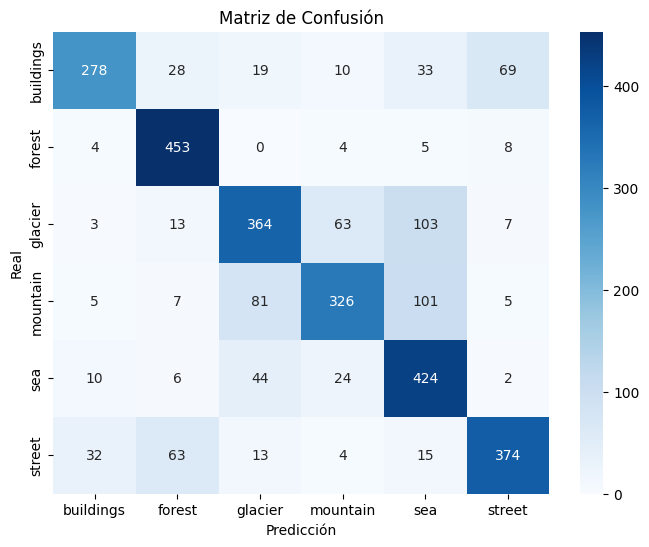

In [33]:
plot_cm(cm_ft, class_names)